In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
LATENT_DIM   = 100
IMAGE_SIZE   = 64
CHANNELS     = 1
FEATURES_G   = 64
FEATURES_D   = 64
BATCH_SIZE   = 128
NUM_EPOCHS   = 50
LR_G         = 0.0002
LR_D         = 0.0001
BETA1        = 0.5
BETA2        = 0.999
REAL_LABEL   = 0.9
FAKE_LABEL   = 0.0
CLIP_VALUE   = 1.0

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset    = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Dataset size   : {len(dataset)} images")
print(f"Batches/epoch  : {len(dataloader)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]

Dataset size   : 60000 images
Batches/epoch  : 469


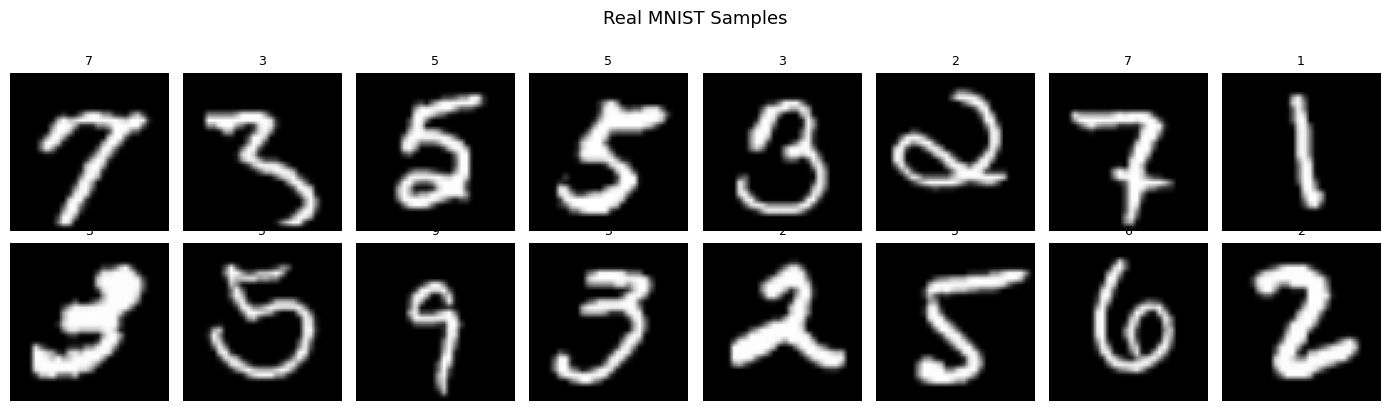

In [4]:
real_batch = next(iter(dataloader))
fig, axes  = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = real_batch[0][i].squeeze().numpy()
    img = (img + 1) / 2
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(real_batch[1][i].item(), fontsize=9)
plt.suptitle("Real MNIST Samples", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("real_samples.png", bbox_inches='tight')
plt.show()

In [5]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, features_g, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim,       features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8,   features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4,   features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2,   features_g,     4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g,       channels,       4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class Discriminator(nn.Module):
    def __init__(self, channels, features_d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels,         features_d,     4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d,       features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 2,   features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 4,   features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 8,   1,              4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [8]:
G = Generator(LATENT_DIM, FEATURES_G, CHANNELS).to(device)
D = Discriminator(CHANNELS, FEATURES_D).to(device)

initialize_weights(G)
initialize_weights(D)

print("Generator")
print(G)
print(f"Parameters: {sum(p.numel() for p in G.parameters()):,}")
print("\nDiscriminator")
print(D)
print(f"Parameters: {sum(p.numel() for p in D.parameters()):,}")

Generator
Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh

In [9]:
criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

fixed_noise = torch.randn(64, LATENT_DIM, 1, 1).to(device)

Starting Training...
Epoch [01/50] | Loss_D: 1.2586 | Loss_G: 4.3937 | D(x): 0.6624 | D(G(z)): 0.1276


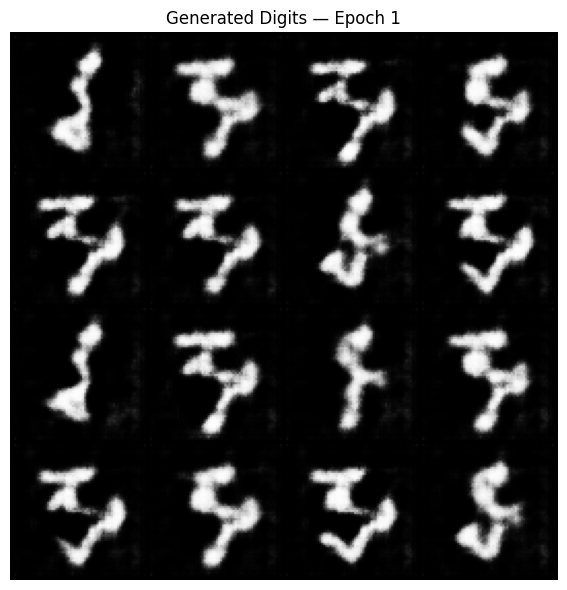

Epoch [02/50] | Loss_D: 1.2450 | Loss_G: 2.0321 | D(x): 0.5772 | D(G(z)): 0.2203
Epoch [03/50] | Loss_D: 1.0040 | Loss_G: 2.4448 | D(x): 0.6495 | D(G(z)): 0.1634
Epoch [04/50] | Loss_D: 0.9287 | Loss_G: 2.7970 | D(x): 0.6803 | D(G(z)): 0.1314
Epoch [05/50] | Loss_D: 0.8671 | Loss_G: 3.0493 | D(x): 0.7004 | D(G(z)): 0.1095
Epoch [06/50] | Loss_D: 0.8282 | Loss_G: 3.1894 | D(x): 0.7127 | D(G(z)): 0.1065
Epoch [07/50] | Loss_D: 0.7293 | Loss_G: 3.6533 | D(x): 0.7386 | D(G(z)): 0.0768
Epoch [08/50] | Loss_D: 0.7002 | Loss_G: 3.7991 | D(x): 0.7542 | D(G(z)): 0.0710
Epoch [09/50] | Loss_D: 0.6517 | Loss_G: 4.1521 | D(x): 0.7581 | D(G(z)): 0.0509
Epoch [10/50] | Loss_D: 0.5864 | Loss_G: 4.2612 | D(x): 0.7841 | D(G(z)): 0.0428


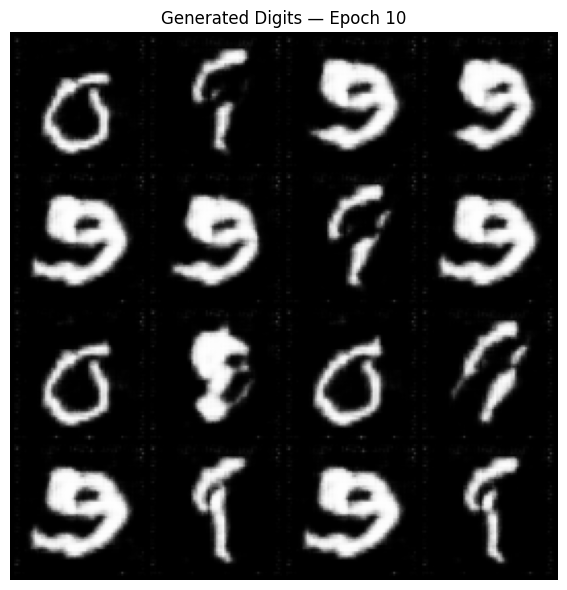

Epoch [11/50] | Loss_D: 0.5604 | Loss_G: 4.3213 | D(x): 0.7836 | D(G(z)): 0.0369
Epoch [12/50] | Loss_D: 0.5766 | Loss_G: 4.4182 | D(x): 0.7747 | D(G(z)): 0.0348
Epoch [13/50] | Loss_D: 0.5650 | Loss_G: 4.5071 | D(x): 0.7734 | D(G(z)): 0.0305
Epoch [14/50] | Loss_D: 0.5465 | Loss_G: 4.4853 | D(x): 0.7794 | D(G(z)): 0.0305
Epoch [15/50] | Loss_D: 0.5029 | Loss_G: 4.8109 | D(x): 0.8005 | D(G(z)): 0.0197
Epoch [16/50] | Loss_D: 0.4835 | Loss_G: 4.6433 | D(x): 0.8099 | D(G(z)): 0.0217
Epoch [17/50] | Loss_D: 0.4885 | Loss_G: 4.7432 | D(x): 0.7976 | D(G(z)): 0.0197
Epoch [18/50] | Loss_D: 0.4831 | Loss_G: 4.9419 | D(x): 0.8038 | D(G(z)): 0.0156
Epoch [19/50] | Loss_D: 0.4835 | Loss_G: 4.8165 | D(x): 0.8074 | D(G(z)): 0.0181
Epoch [20/50] | Loss_D: 0.4656 | Loss_G: 5.0398 | D(x): 0.8098 | D(G(z)): 0.0132


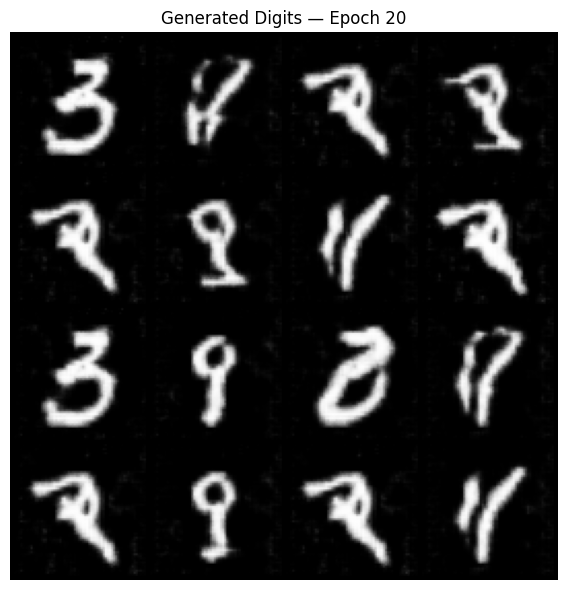

Epoch [21/50] | Loss_D: 0.4463 | Loss_G: 5.1042 | D(x): 0.8175 | D(G(z)): 0.0114
Epoch [22/50] | Loss_D: 0.4733 | Loss_G: 4.8989 | D(x): 0.8040 | D(G(z)): 0.0155
Epoch [23/50] | Loss_D: 0.4396 | Loss_G: 5.0495 | D(x): 0.8173 | D(G(z)): 0.0115
Epoch [24/50] | Loss_D: 0.4517 | Loss_G: 4.9922 | D(x): 0.8071 | D(G(z)): 0.0122
Epoch [25/50] | Loss_D: 0.4431 | Loss_G: 5.1391 | D(x): 0.8177 | D(G(z)): 0.0117
Epoch [26/50] | Loss_D: 0.4550 | Loss_G: 5.2216 | D(x): 0.8064 | D(G(z)): 0.0107
Epoch [27/50] | Loss_D: 0.4520 | Loss_G: 5.2480 | D(x): 0.8062 | D(G(z)): 0.0096
Epoch [28/50] | Loss_D: 0.4503 | Loss_G: 5.1793 | D(x): 0.8120 | D(G(z)): 0.0118
Epoch [29/50] | Loss_D: 0.4144 | Loss_G: 5.4358 | D(x): 0.8312 | D(G(z)): 0.0069
Epoch [30/50] | Loss_D: 0.4257 | Loss_G: 5.3245 | D(x): 0.8210 | D(G(z)): 0.0085


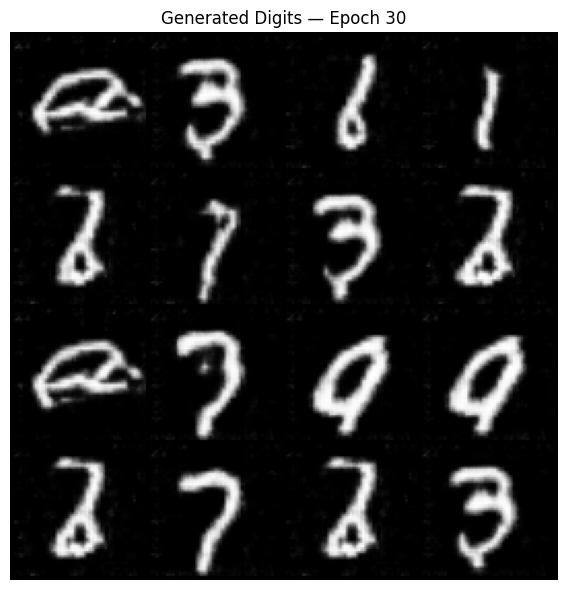

Epoch [31/50] | Loss_D: 0.4423 | Loss_G: 5.1533 | D(x): 0.8105 | D(G(z)): 0.0104
Epoch [32/50] | Loss_D: 0.4251 | Loss_G: 5.2727 | D(x): 0.8203 | D(G(z)): 0.0087
Epoch [33/50] | Loss_D: 0.4408 | Loss_G: 5.5014 | D(x): 0.8128 | D(G(z)): 0.0075
Epoch [34/50] | Loss_D: 0.4233 | Loss_G: 5.3486 | D(x): 0.8215 | D(G(z)): 0.0082
Epoch [35/50] | Loss_D: 0.4111 | Loss_G: 5.4518 | D(x): 0.8270 | D(G(z)): 0.0069
Epoch [36/50] | Loss_D: 0.4387 | Loss_G: 5.5290 | D(x): 0.8101 | D(G(z)): 0.0076
Epoch [37/50] | Loss_D: 0.4465 | Loss_G: 5.4326 | D(x): 0.8089 | D(G(z)): 0.0093
Epoch [38/50] | Loss_D: 0.4263 | Loss_G: 5.5258 | D(x): 0.8191 | D(G(z)): 0.0075
Epoch [39/50] | Loss_D: 0.4262 | Loss_G: 5.6121 | D(x): 0.8173 | D(G(z)): 0.0067
Epoch [40/50] | Loss_D: 0.4166 | Loss_G: 5.6725 | D(x): 0.8224 | D(G(z)): 0.0064


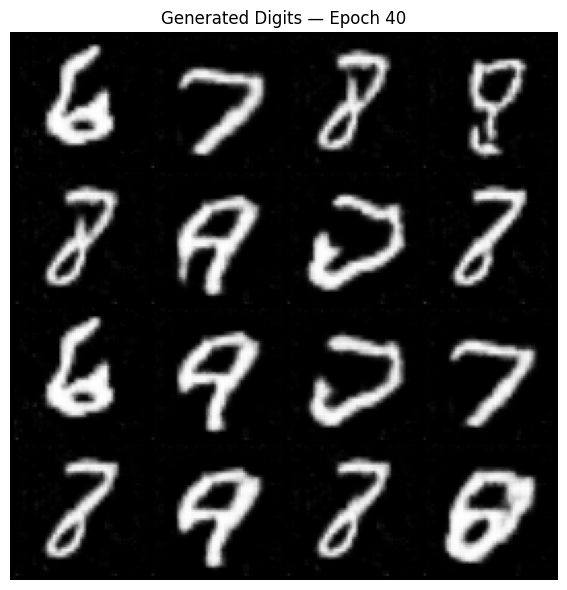

Epoch [41/50] | Loss_D: 0.4171 | Loss_G: 5.6332 | D(x): 0.8213 | D(G(z)): 0.0071
Epoch [42/50] | Loss_D: 0.3979 | Loss_G: 5.6746 | D(x): 0.8359 | D(G(z)): 0.0058
Epoch [43/50] | Loss_D: 0.4090 | Loss_G: 5.8503 | D(x): 0.8245 | D(G(z)): 0.0052
Epoch [44/50] | Loss_D: 0.4111 | Loss_G: 5.8161 | D(x): 0.8252 | D(G(z)): 0.0056
Epoch [45/50] | Loss_D: 0.3975 | Loss_G: 5.8343 | D(x): 0.8322 | D(G(z)): 0.0052
Epoch [46/50] | Loss_D: 0.4054 | Loss_G: 6.0699 | D(x): 0.8279 | D(G(z)): 0.0043
Epoch [47/50] | Loss_D: 0.4053 | Loss_G: 5.8730 | D(x): 0.8324 | D(G(z)): 0.0064
Epoch [48/50] | Loss_D: 0.3967 | Loss_G: 5.8077 | D(x): 0.8344 | D(G(z)): 0.0064
Epoch [49/50] | Loss_D: 0.4011 | Loss_G: 6.1274 | D(x): 0.8250 | D(G(z)): 0.0040
Epoch [50/50] | Loss_D: 0.3964 | Loss_G: 6.1776 | D(x): 0.8340 | D(G(z)): 0.0041


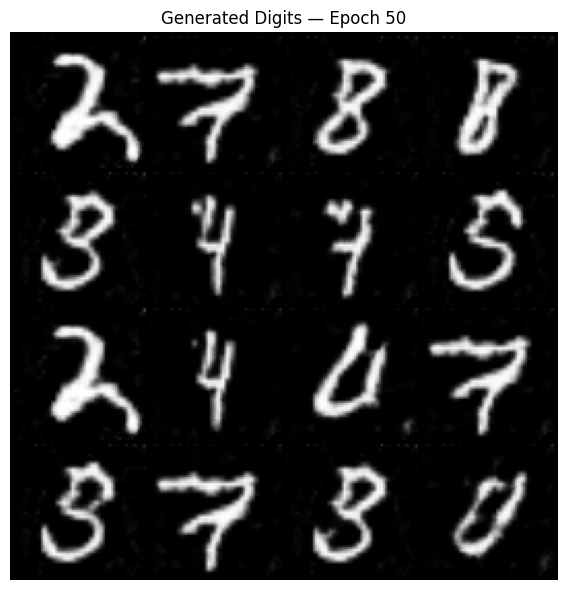

Training complete!


In [10]:
os.makedirs("generated_images", exist_ok=True)

G_losses       = []
D_losses       = []
D_real_scores  = []
D_fake_scores  = []

print("Starting Training...")
print("=" * 65)

for epoch in range(NUM_EPOCHS):
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    epoch_D_real = 0.0
    epoch_D_fake = 0.0

    for real_imgs, _ in dataloader:
        real_imgs  = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.full((batch_size, 1, 1, 1), REAL_LABEL, device=device)
        fake_labels = torch.full((batch_size, 1, 1, 1), FAKE_LABEL, device=device)

        D.zero_grad()
        out_real = D(real_imgs)
        loss_real = criterion(out_real, real_labels)
        D_x = out_real.mean().item()

        noise     = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        out_fake  = D(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        nn.utils.clip_grad_norm_(D.parameters(), CLIP_VALUE)
        opt_D.step()

        total_G_loss = 0.0
        for _ in range(2):
            G.zero_grad()
            noise2    = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake2     = G(noise2)
            out_g     = D(fake2)
            loss_G    = criterion(out_g, real_labels[:fake2.size(0)])
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), CLIP_VALUE)
            opt_G.step()
            total_G_loss += loss_G.item()

        D_G_z = out_g.mean().item()

        epoch_D_loss += loss_D.item()
        epoch_G_loss += total_G_loss / 2
        epoch_D_real += D_x
        epoch_D_fake += D_G_z

    n = len(dataloader)
    avg_D  = epoch_D_loss / n
    avg_G  = epoch_G_loss / n
    avg_Dr = epoch_D_real / n
    avg_Df = epoch_D_fake / n

    G_losses.append(avg_G)
    D_losses.append(avg_D)
    D_real_scores.append(avg_Dr)
    D_fake_scores.append(avg_Df)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
          f"Loss_D: {avg_D:.4f} | Loss_G: {avg_G:.4f} | "
          f"D(x): {avg_Dr:.4f} | D(G(z)): {avg_Df:.4f}")

    if (epoch + 1) % 10 == 0 or epoch == 0:
        G.eval()
        with torch.no_grad():
            fake_samples = G(fixed_noise).cpu()
        G.train()
        grid = torchvision.utils.make_grid(fake_samples[:16], nrow=4, normalize=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.axis('off')
        ax.set_title(f"Generated Digits — Epoch {epoch+1}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"generated_images/epoch_{epoch+1:02d}.png", dpi=100, bbox_inches='tight')
        plt.show()

print("=" * 65)
print("Training complete!")

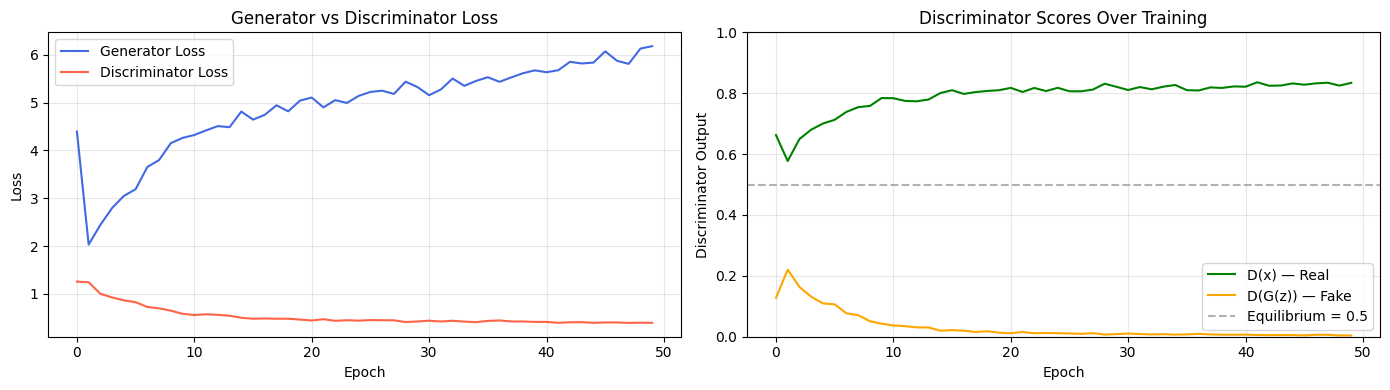

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(G_losses, label='Generator Loss',      color='royalblue')
axes[0].plot(D_losses, label='Discriminator Loss',  color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Generator vs Discriminator Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(D_real_scores, label='D(x) — Real',   color='green')
axes[1].plot(D_fake_scores, label='D(G(z)) — Fake',color='orange')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='Equilibrium = 0.5')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Discriminator Output')
axes[1].set_title('Discriminator Scores Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100, bbox_inches='tight')
plt.show()

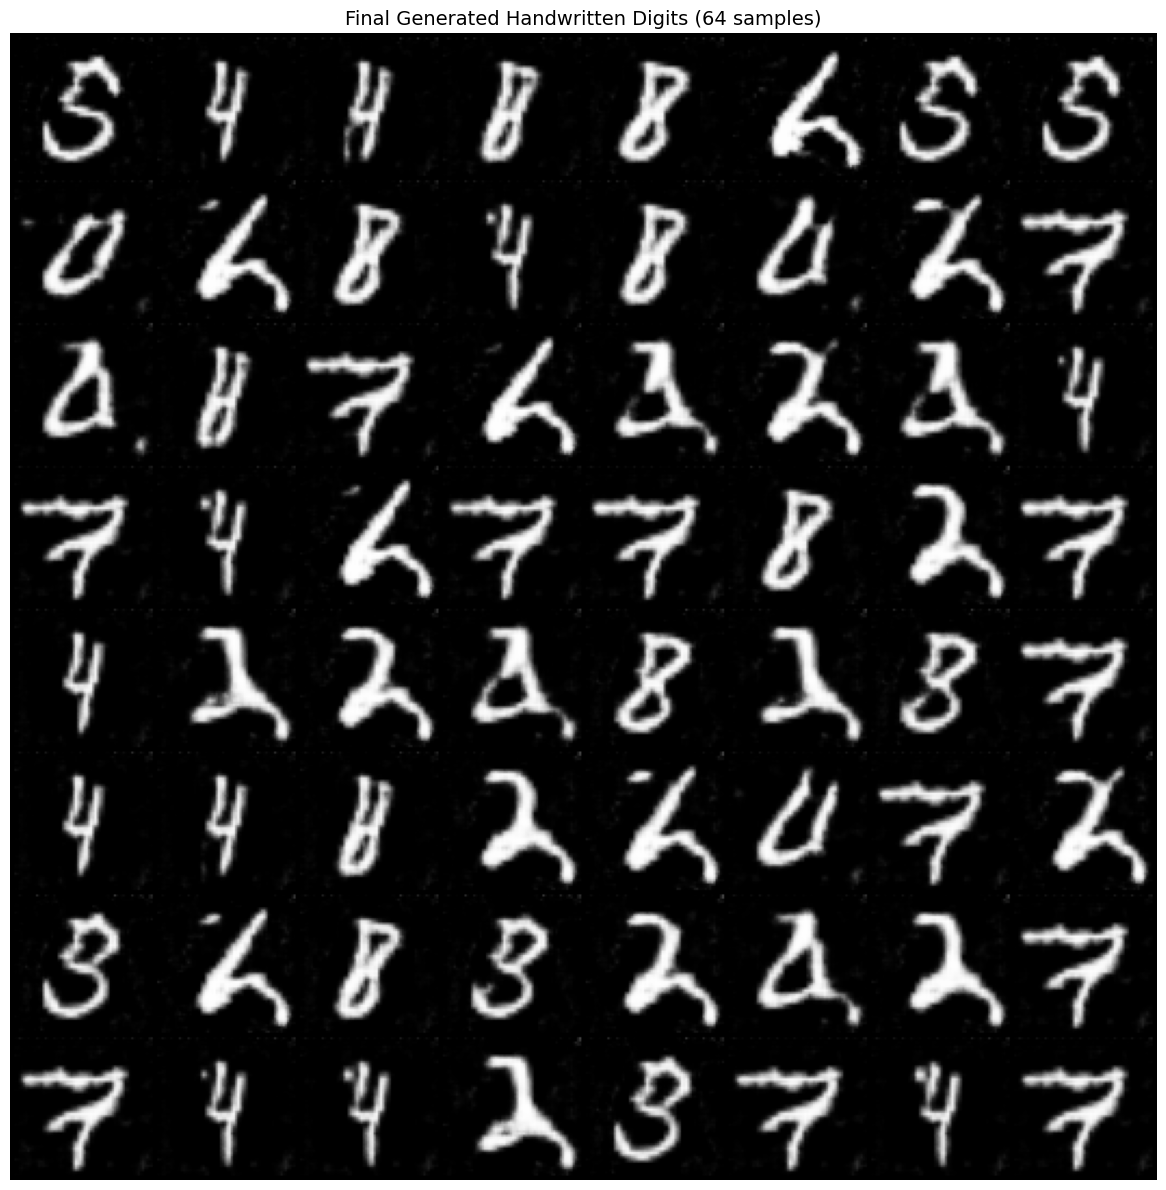

Saved: final_generated_samples.png


In [12]:
G.eval()
with torch.no_grad():
    final_noise   = torch.randn(64, LATENT_DIM, 1, 1).to(device)
    final_samples = G(final_noise).cpu()

grid = torchvision.utils.make_grid(final_samples, nrow=8, normalize=True)
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
ax.axis('off')
ax.set_title("Final Generated Handwritten Digits (64 samples)", fontsize=14)
plt.tight_layout()
plt.savefig("final_generated_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_generated_samples.png")

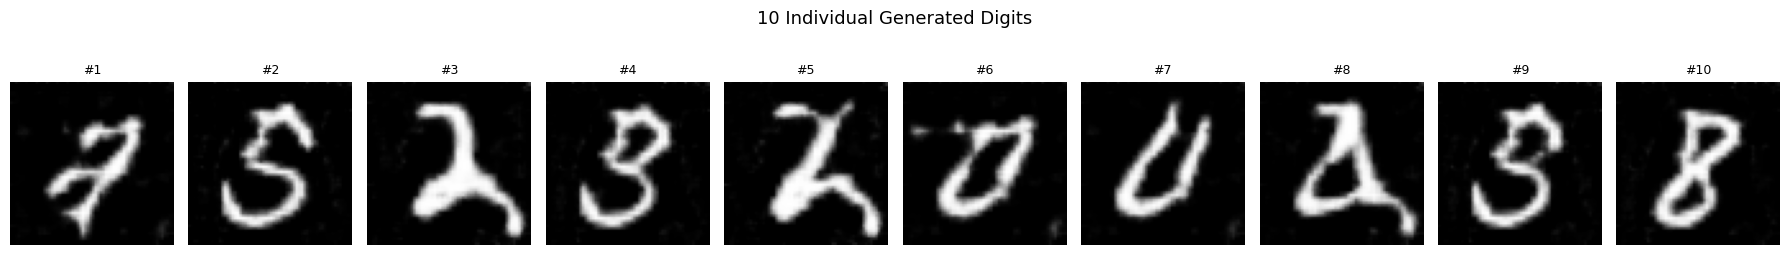

Saved: ten_generated_digits.png


In [13]:
G.eval()
with torch.no_grad():
    showcase_noise   = torch.randn(10, LATENT_DIM, 1, 1).to(device)
    showcase_samples = G(showcase_noise).cpu()

fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
for i, ax in enumerate(axes):
    img = showcase_samples[i].squeeze().numpy()
    img = (img + 1) / 2
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"#{i+1}", fontsize=9)

plt.suptitle("10 Individual Generated Digits", fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig("ten_generated_digits.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ten_generated_digits.png")

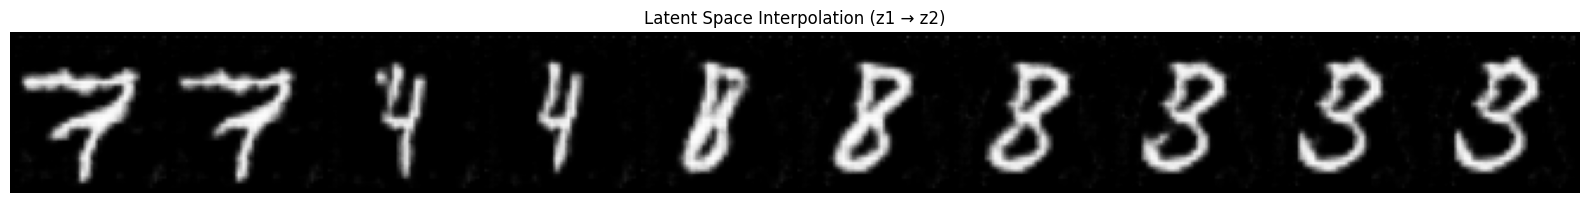

In [14]:
G.eval()
z1 = torch.randn(1, LATENT_DIM, 1, 1).to(device)
z2 = torch.randn(1, LATENT_DIM, 1, 1).to(device)

steps = 10
interp_imgs = []

with torch.no_grad():
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        interp_imgs.append(G(z_interp).cpu())

interp_tensor = torch.cat(interp_imgs, dim=0)
grid = torchvision.utils.make_grid(interp_tensor, nrow=steps, normalize=True)

fig, ax = plt.subplots(figsize=(16, 2.5))
ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
ax.axis('off')
ax.set_title("Latent Space Interpolation (z1 → z2)", fontsize=12)
plt.tight_layout()
plt.savefig("latent_interpolation.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
torch.save(G.state_dict(), "generator_final.pth")
torch.save(D.state_dict(), "discriminator_final.pth")
print("Models saved successfully.")

Models saved successfully.


## 12. Summary & Observations

### Architecture Summary

| Component | Details |
|---|---|
| Generator Input | Latent vector z ∈ R^100 |
| Generator Output | 64×64 grayscale image |
| Discriminator Input | 64×64 grayscale image |
| Discriminator Output | Scalar ∈ [0, 1] |
| G Layers | 5× ConvTranspose2d + BatchNorm + ReLU, Tanh output |
| D Layers | 5× Conv2d + BatchNorm + LeakyReLU(0.2), Sigmoid output |
| G Optimizer | Adam, lr=0.0002, β1=0.5 |
| D Optimizer | Adam, lr=0.0001, β1=0.5 |
| Loss | Binary Cross Entropy |
| Label Smoothing | Real = 0.9, Fake = 0.0 |
| G Updates / Batch | 2 (vs 1 for D) |
| Gradient Clip | max norm = 1.0 |

### Key Observations

- **Early epochs:** The generator produces blurry blobs. The discriminator quickly learns to separate real from fake, reflected by high D(x) and low D(G(z)).
- **Mid training:** With label smoothing and double G updates, the discriminator can no longer completely dominate. D(G(z)) rises as the generator learns meaningful structure.
- **Late epochs:** Both D(x) and D(G(z)) hover near 0.5, indicating a healthy adversarial equilibrium. Generated digits show clear stroke patterns consistent with handwritten numerals.
- **Latent space:** Linear interpolation between two noise vectors produces smooth, continuous transitions confirming the generator has learned a structured latent representation.

### Stability Challenges

Without label smoothing, the discriminator's cross-entropy loss approaches zero when it classifies all real images as real with probability 1. At this point the gradient signal flowing back to the generator essentially vanishes — the generator has no information about how to improve, so its loss explodes. This is what caused the collapse observed in the raw training run (epochs 28–32). The fixes applied here — smoothed labels, a slower discriminator learning rate, double generator updates, and gradient clipping — all work to keep the two networks competitively matched throughout training.